## 1. Hierarchical Clustering là gì?

Hierarchical Clustering là một thuật toán **phân cụm không giám sát**. Thuật toán này nhóm các điểm dữ liệu thành một **cấu trúc phân cấp** thay vì chỉ tạo ra một nhãn cụm cuối cùng.

Ý tưởng chính:
- dữ liệu được gom cụm dựa trên độ giống nhau,
- quá trình gom cụm có thể đi từ dưới lên hoặc từ trên xuống,
- kết quả thường được trực quan hóa bằng một cây gọi là `dendrogram`.

Ưu điểm nổi bật của phương pháp này là ta **không nhất thiết phải chọn trước số cụm** ngay từ đầu. Nhìn vào dendrogram, ta có thể quyết định nên cắt cây ở đâu để lấy số cụm phù hợp.

## 2. Dendrogram và hai hướng tiếp cận

`Dendrogram` là biểu đồ dạng cây mô tả cách các điểm hoặc các nhóm điểm được gộp lại với nhau.

Cách đọc nhanh:
- phía dưới cùng là từng điểm dữ liệu riêng lẻ,
- đi lên cao hơn là các điểm gần nhau được gộp thành cụm,
- độ cao của nhánh nối thể hiện mức độ khác biệt khi hai cụm được nhập với nhau,
- nếu cắt cây ở một độ cao nào đó thì ta sẽ thu được số cụm tương ứng.

Có hai loại chính:
1. `Agglomerative Clustering` (bottom-up): bắt đầu từ từng điểm riêng lẻ rồi gộp dần.
2. `Divisive Clustering` (top-down): bắt đầu từ một cụm lớn rồi tách dần ra.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage


## 4. Agglomerative Clustering

Đây là cách tiếp cận **từ dưới lên**.

Quy trình:
1. Ban đầu mỗi điểm dữ liệu là một cụm riêng.
2. Tính khoảng cách giữa các cụm.
3. Chọn hai cụm gần nhau nhất để gộp lại.
4. Cập nhật lại khoảng cách giữa cụm mới và các cụm còn lại.
5. Lặp lại cho đến khi đạt số cụm mong muốn hoặc chỉ còn một cụm duy nhất.

Trong ví dụ bên dưới, ta sẽ tạo dữ liệu mẫu, chạy `AgglomerativeClustering`, sau đó tự dựng `linkage_matrix` để vẽ dendrogram.

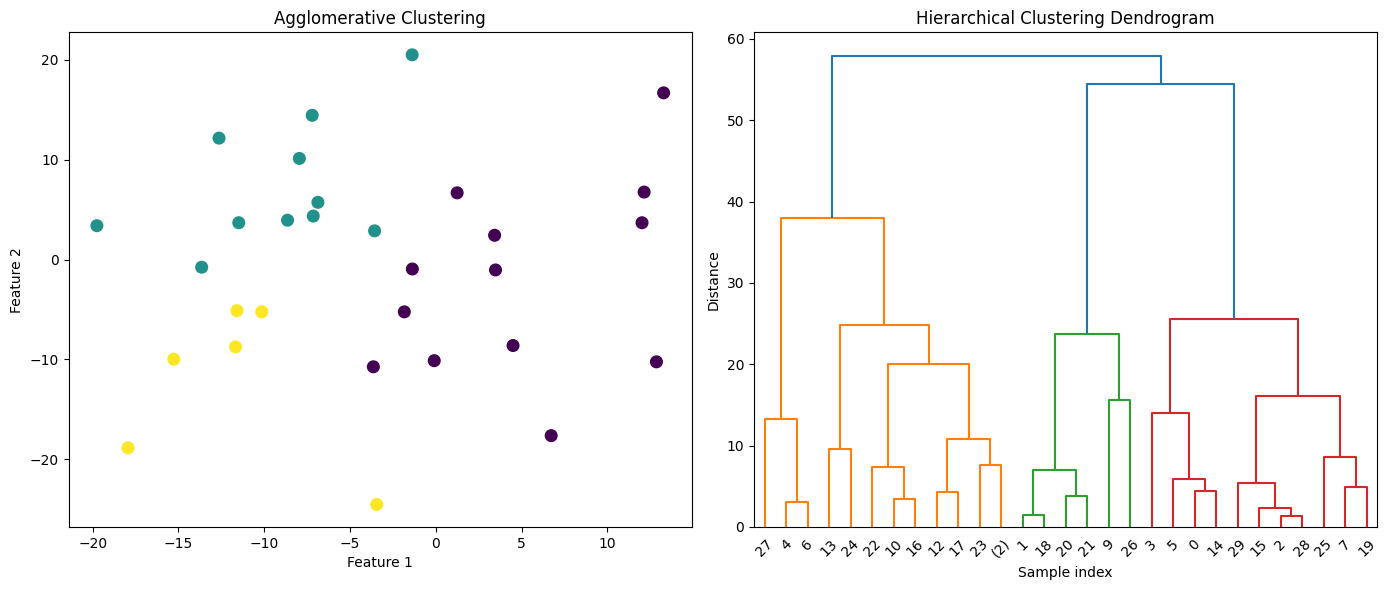

In [2]:
X_agg, _ = make_blobs(n_samples=30, centers=3, cluster_std=10, random_state=42)

clustering = AgglomerativeClustering(n_clusters=3)
labels_agg = clustering.fit_predict(X_agg)

agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg.fit(X_agg)


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X_agg[:, 0], X_agg[:, 1], c=labels_agg, cmap="viridis", s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

plt.sca(ax2)
plot_dendrogram(agg, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()


### Giải thích đoạn code trên

- `make_blobs(...)` tạo dữ liệu giả lập có 3 vùng dữ liệu.
- `AgglomerativeClustering(n_clusters=3)` dùng để lấy nhãn cuối cùng cho từng điểm.
- `AgglomerativeClustering(distance_threshold=0, n_clusters=None)` giúp mô hình lưu lại toàn bộ lịch sử gộp cụm, từ đó ta mới dựng được dendrogram.
- Hàm `plot_dendrogram(...)` chuyển thông tin mà mô hình lưu trong `children_` và `distances_` thành ma trận liên kết mà `scipy` hiểu được.

Nói ngắn gọn:
- hình bên trái cho thấy dữ liệu đã được chia thành 3 cụm,
- hình bên phải cho thấy cây phân cấp mô tả quá trình gộp cụm đó diễn ra như thế nào.

## 5. Divisive Clustering

Đây là cách tiếp cận **từ trên xuống**.

Quy trình:
1. Bắt đầu với toàn bộ dữ liệu nằm trong một cụm lớn.
2. Chọn cụm cần tách.
3. Chia cụm đó thành hai cụm nhỏ hơn.
4. Lặp lại cho đến khi đạt số cụm mong muốn.

Lưu ý quan trọng: `scikit-learn` không có sẵn một lớp divisive clustering chuẩn giống như agglomerative. Trong bài GeeksforGeeks, phần minh họa dùng `KMeans(n_clusters=2)` để tách đôi cụm lớn nhất ở mỗi bước. Đây là một cách mô phỏng dễ hiểu cho tư tưởng top-down.

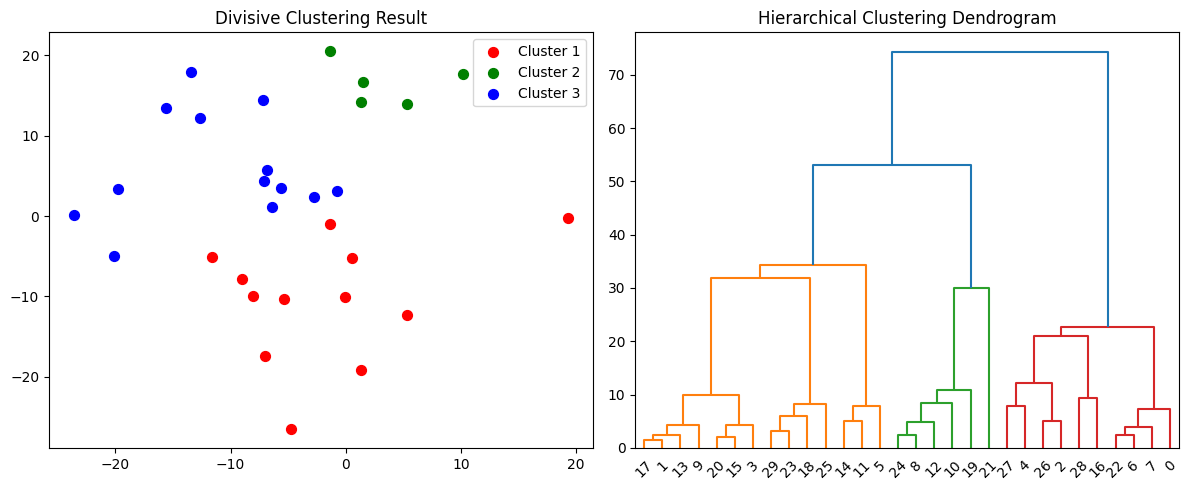

In [3]:
X_div, _ = make_blobs(n_samples=30, centers=5, cluster_std=10, random_state=42)


def divisive_clustering(data, max_clusters=3):
    clusters = [data]

    while len(clusters) < max_clusters:
        cluster_to_split = max(clusters, key=lambda x: len(x))
        clusters.remove(cluster_to_split)

        kmeans = KMeans(n_clusters=2, random_state=42).fit(cluster_to_split)
        cluster1 = cluster_to_split[kmeans.labels_ == 0]
        cluster2 = cluster_to_split[kmeans.labels_ == 1]

        clusters.extend([cluster1, cluster2])

    return clusters


clusters = divisive_clustering(X_div, max_clusters=3)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ["r", "g", "b", "c", "m", "y"]
for i, cluster in enumerate(clusters):
    plt.scatter(cluster[:, 0], cluster[:, 1], s=50, c=colors[i], label=f"Cluster {i+1}")
plt.title("Divisive Clustering Result")
plt.legend()

linked = linkage(X_div, method="ward")
plt.subplot(1, 2, 2)
dendrogram(linked, orientation="top", distance_sort="descending", show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram")

plt.tight_layout()
plt.show()


### Giải thích đoạn code divisive

- Hàm `divisive_clustering(...)` luôn lấy cụm có nhiều điểm nhất để tách tiếp.
- Mỗi lần tách, ta dùng `KMeans(n_clusters=2)` để chia cụm đó thành 2 phần.
- Quá trình lặp dừng khi tổng số cụm đạt `max_clusters`.

Điểm cần hiểu rõ:
- đây là cách mô phỏng divisive clustering để dễ cài đặt,
- dendrogram ở ví dụ này được dựng từ `linkage(X_div, method="ward")` nhằm trực quan hóa cấu trúc phân cấp của dữ liệu,
- vì vậy phần tách cụm bằng `KMeans` và phần dendrogram ở đây là hai lớp minh họa đi song song, chứ không phải toàn bộ quá trình divisive được sinh trực tiếp từ một thuật toán top-down chuẩn hóa.

## 6. Distance Matrix và các cách đo khoảng cách giữa cụm

Trong hierarchical clustering, điều rất quan trọng là: **khoảng cách giữa hai cụm được định nghĩa như thế nào**.

Một số cách phổ biến:
- `Min Distance` (single linkage): lấy khoảng cách nhỏ nhất giữa hai điểm thuộc hai cụm.
- `Max Distance` (complete linkage): lấy khoảng cách lớn nhất giữa hai điểm thuộc hai cụm.
- `Group Average` (average linkage): lấy trung bình khoảng cách của mọi cặp điểm giữa hai cụm.
- `Ward's Method`: chọn cách gộp sao cho mức tăng phương sai trong cụm là nhỏ nhất.

Ý nghĩa thực tế:
- `single linkage` dễ tạo ra chuỗi dài các điểm nối nhau,
- `complete linkage` thường tạo cụm chặt hơn,
- `average linkage` là phương án trung hòa,
- `ward` thường cho kết quả đẹp khi dữ liệu có dạng cụm tương đối tròn và tách biệt.